## Introduction

The [ZymoBIOMICS mock microbial community](https://github.com/LomanLab/mockcommunity) is a standardized mixture of known bacterial and fungal taxa at defined proportions. Because the true composition is known, it is widely used as a benchmarking and proof-of-concept dataset for evaluating bioinformatics pipelines, feature representations, and ecological analysis methods.

In this homework, you will use the Zymo mock community as a controlled testbed to assess the quality of **GenSLMs sequence embeddings**.



### Background

GenSLMs embeddings are pretrained representations derived from the **GenSLM foundation model** (GitHub: https://github.com/ramanathanlab/genslm).  
They are intended to capture biologically meaningful patterns such as evolutionary or phylogenetic relatedness and shared functional motifs.

There are 10 reference genomes in this dataset. Metagenomic reads have been assembled into contigs. The reference genome IDs correspond to:

- **0**: *Bacillus subtilis*
- **1**: *Cryptococcus neoformans*
- **2**: *Enterococcus faecalis*
- **3**: *Escherichia coli*
- **4**: *Lactobacillus fermentum*
- **5**: *Listeria monocytogenes*
- **6**: *Pseudomonas aeruginosa*
- **7**: *Saccharomyces cerevisiae*
- **8**: *Salmonella enterica*
- **9**: *Staphylococcus aureus*

Among these genomes, **E. coli** and **Salmonella** share ~87.04% similarity, and **Bacillus** and **Staphylococcus** share ~72.25% similarity.



### Hypothesis

We hypothesize that GenSLMs embeddings encode evolutionary and functional signals strongly enough that:

1. A classifier trained on the embeddings can accurately predict contig origin (genome ID).
2. Low-dimensional projections (PCA / UMAP / t-SNE) reveal coherent clusters aligned with genome IDs, including known similarity pairs (e.g., *E. coli* vs. *Salmonella*).
3. Clustering algorithms applied to the embeddings approximate true contig origin groupings with high homogeneity and completeness.



### Strategy

1. Load contig-level embeddings and genome IDs.
2. Perform a stratified train/test split to evaluate generalization.
3. Train multiple multi-class classifiers (Logistic Regression, LightGBM, XGBoost, CatBoost) and select the best model based on macro F1.
4. To speed up classification, reduce the dimensionality using PCA and UMAP, and evaluate how different numbers of components affect classification performance.
5. Visualize the embeddings using PCA, t-SNE, and UMAP with tuned hyperparameters; annotate notable overlaps (e.g., *E. coli* vs. *Salmonella*).
6. Apply clustering (DBSCAN / HDBSCAN / KMeans) on the 2D reduced space and compute homogeneity and completeness scores.




### Evaluation

- **Classification**: macro precision, macro recall, macro F1, accuracy.
- **Visualization**: qualitative cluster separation and overlapping
- **Clustering**: homogeneity_score, completeness_score, number of clusters vs expected genomes, outlier count (if applicable).


### Open-Ended Nature

This assignment is intentionally open-ended — there is no single “correct” setting.  
You are encouraged to explore reasonable hyperparameters.  
For some steps, I also provide my own settings so that everyone starts from the same baseline.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [3]:
genslm_npz = np.load("zymo_genslm_embeddings.npz")
genslm_npz['e'].shape
genslm_npz['id'].shape

(11724,)

In [4]:
genslm_embed = pd.DataFrame(genslm_npz['e'])
genslm_embed['rid'] = genslm_npz['id']
genslm_embed=genslm_embed.sample(frac=1)
genslm_embed.describe()

,0,1,2,3,4,5,6,7,8,9,...,3831,3832,3833,3834,3835,3836,3837,3838,3839,rid
count,11724.000000,11724.000000,11724.000000,11724.000000,11724.000000,11724.000000,11724.000000,11724.000000,11724.000000,11724.000000,...,11724.000000,11724.000000,11724.000000,11724.000000,11724.000000,11724.000000,11724.000000,11724.000000,11724.000000,11724.000000
mean,-0.172946,0.229652,-0.091656,0.312128,0.221963,-0.049410,0.394963,-0.066101,0.109899,0.072875,...,0.035922,0.245670,0.310494,-0.097445,-0.038705,-0.068324,-0.027750,-0.171403,-1.567976,2.696691
std,0.107995,0.070312,0.091085,0.130253,0.260921,0.037091,0.111554,0.044227,0.169603,0.072104,...,0.045836,0.076481,0.064397,0.149072,0.061731,0.055843,0.054115,0.165558,0.234705,2.662503
min,-0.414492,-0.170474,-0.428855,-0.189030,-0.202179,-0.231486,-0.068627,-0.311310,-0.246488,-0.289764,...,-0.243446,-0.108656,-0.095644,-0.376422,-0.333230,-0.330913,-0.217874,-0.518213,-1.966708,0.000000
25%,-0.281451,0.188339,-0.169851,0.190794,-0.047185,-0.071939,0.291742,-0.092717,-0.059577,0.012137,...,0.006500,0.183361,0.254403,-0.253409,-0.074627,-0.115565,-0.069625,-0.334869,-1.811119,1.000000
50%,-0.158354,0.232108,-0.103474,0.328118,0.260320,-0.047380,0.402840,-0.067295,0.129721,0.075557,...,0.037762,0.241674,0.312618,-0.076764,-0.044577,-0.072631,-0.030407,-0.139756,-1.547125,1.000000
75%,-0.075722,0.270721,-0.017998,0.433676,0.481040,-0.026329,0.496704,-0.042365,0.272931,0.133934,...,0.065301,0.317796,0.364526,0.041555,-0.002921,-0.017938,0.012859,-0.010328,-1.341360,5.000000
max,0.226545,0.548050,0.216811,0.691828,0.913784,0.229549,0.696488,0.149715,0.717532,0.328994,...,0.212165,0.430578,0.599509,0.401128,0.167531,0.099039,0.294926,0.475211,-0.598945,9.000000


In [5]:
# show the value count of the rid
genslm_embed['rid'].value_counts()

rid
1    7210
7    1326
6     694
3     519
8     496
0     405
5     297
2     284
9     282
4     211
Name: count, dtype: int64

In [6]:
# split the data into feature and target
X = genslm_embed.iloc[:, :-1].values
y = genslm_embed.iloc[:, -1].values

# split the data into training and test set with stratify
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y)

In [27]:
# scale the data
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

## Task 1: Multi-Class Classification (20 points)

Apply multiple classifiers to the dataset and identify the best-performing model based on the **macro F1 score**.  
The classifiers to evaluate include: **Multinomial Logistic Regression, LightGBM, XGBoost, and CatBoost**.

Please display the performance metrics for each classifier (e.g., **accuracy, macro precision, macro recall, macro F1**) to justify your selection of the top model for the downstream tasks.

In [38]:
# Set PyTorch as the backend for Keras before importing Keras
import os
os.environ["KERAS_BACKEND"] = "torch"

# Now import Keras (it will use PyTorch as backend)
import keras
from keras.models import Sequential
from keras.layers import Dense

# build a neural network classifier on the data
keras_classifier = Sequential(
    [
        Dense(25, activation = 'relu'),
        Dense(15, activation = 'relu'),
        Dense(10, activation = 'softmax')    # < softmax activation here
    ]
)

keras_classifier.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(),
    optimizer=keras.optimizers.Adam(0.001),
)

from keras.callbacks import EarlyStopping
early_stop = EarlyStopping(monitor='val_loss', patience=5, start_from_epoch=10,
                           restore_best_weights=True)

keras_classifier.fit(
    X_train, y_train,
    epochs=40,
    callbacks = [early_stop]
)


Epoch 1/40
294/294 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 1.0292
Epoch 2/40
 25/294 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.4944

/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/early_stopping.py:153: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: loss
  current = self.get_monitor_value(logs)


294/294 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.3934
Epoch 3/40
294/294 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.2551
Epoch 4/40
294/294 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.2054
Epoch 5/40
294/294 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.1885
Epoch 6/40
294/294 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.1629
Epoch 7/40
294/294 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.1586
Epoch 8/40
294/294 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.1546
Epoch 9/40
294/294 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.1487
Epoch 10/40
294/294 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.1268
Epoch 11/40
294/294 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.1152
Epoch 12/40
294/294 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.1487
Epoch 13/40
294/294 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.1561
Epoch 14/40
294/294 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0993
Epoch 15/40
294/294 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.1022
Epoch 16/40
294/294 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0884

In [39]:
# show first few predicted probability vectors from the Keras (torch-backend) model
p_nonpreferred = keras_classifier.predict(X_test)

74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [40]:

y_pred = np.argmax(p_nonpreferred, axis=1)

## output the performance metrics
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

## output the precision, recall and f1 score
from sklearn.metrics import precision_score, recall_score, f1_score

print("Precision Multinomial classification: {:.2f}".format(precision_score(y_test, y_pred, average='macro')))
print("Recall Multinomial classification: {:.2f}".format(recall_score(y_test, y_pred, average='macro')))
print("F1 Score Multinomial classification: {:.2f}".format(f1_score(y_test, y_pred, average='macro')))

              precision    recall  f1-score   support

           0       0.94      0.91      0.93        81
           1       0.99      1.00      0.99      1442
           2       0.74      0.89      0.81        57
           3       0.81      0.62      0.71       104
           4       0.95      0.86      0.90        42
           5       0.86      0.70      0.77        60
           6       0.98      1.00      0.99       139
           7       0.94      0.94      0.94       265
           8       0.73      0.84      0.78        99
           9       0.83      0.95      0.88        56

    accuracy                           0.95      2345
   macro avg       0.88      0.87      0.87      2345
weighted avg       0.95      0.95      0.95      2345

Precision Multinomial classification: 0.88
Recall Multinomial classification: 0.87
F1 Score Multinomial classification: 0.87


In [ ]:

print(classification_report(y_test, y_pred_log))

## output the precision, recall and f1 score
from sklearn.metrics import precision_score, recall_score, f1_score

print("Precision: {:.2f}".format(precision_score(y_test, y_pred_log, average='macro')))
print("Recall: {:.2f}".format(recall_score(y_test, y_pred_log, average='macro')))
print("F1 Score: {:.2f}".format(f1_score(y_test, y_pred_log, average='macro')))

In [ ]:
#Now lets use LightGBM
import lightgbm as lgb
lgbm = lgb.LGBMClassifier(objective='multiclass',
                          num_class=10)
lgbm.fit(X_train, y_train)
y_pred_lgbm = lgbm.predict(X_test)
print("LightGBM Classification Report:")
print(classification_report(y_test, y_pred_lgbm))


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.909248 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 979200
[LightGBM] [Info] Number of data points in the train set: 9379, number of used features: 3840
[LightGBM] [Info] Start training from score -3.365485
[LightGBM] [Info] Start training from score -0.486148
[LightGBM] [Info] Start training from score -3.721278
[LightGBM] [Info] Start training from score -3.117950
[LightGBM] [Info] Start training from score -4.016330
[LightGBM] [Info] Start training from score -3.678168
[LightGBM] [Info] Start training from score -2.827260
[LightGBM] [Info] Start training from score -2.179261
[LightGBM] [Info] Start training from score -3.162292
[LightGBM] [Info] Start training from score -3.725693
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warnin

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.88      0.93        81
           1       0.98      1.00      0.99      1442
           2       0.87      0.68      0.76        57
           3       0.71      0.68      0.70       104
           4       1.00      0.88      0.94        42
           5       0.80      0.80      0.80        60
           6       0.99      0.97      0.98       139
           7       0.89      0.95      0.92       265
           8       0.73      0.66      0.69        99
           9       0.91      0.91      0.91        56

    accuracy                           0.94      2345
   macro avg       0.89      0.84      0.86      2345
weighted avg       0.94      0.94      0.94      2345



In [ ]:

#Results from LGBM

print(classification_report(y_test, y_pred_lgbm))

## output the precision, recall and f1 score
from sklearn.metrics import precision_score, recall_score, f1_score

print("Precision: {:.2f}".format(precision_score(y_test, y_pred_lgbm, average='macro')))
print("Recall: {:.2f}".format(recall_score(y_test, y_pred_lgbm, average='macro')))
print("F1 Score: {:.2f}".format(f1_score(y_test, y_pred_lgbm, average='macro')))


              precision    recall  f1-score   support

           0       1.00      0.88      0.93        81
           1       0.98      1.00      0.99      1442
           2       0.87      0.68      0.76        57
           3       0.71      0.68      0.70       104
           4       1.00      0.88      0.94        42
           5       0.80      0.80      0.80        60
           6       0.99      0.97      0.98       139
           7       0.89      0.95      0.92       265
           8       0.73      0.66      0.69        99
           9       0.91      0.91      0.91        56

    accuracy                           0.94      2345
   macro avg       0.89      0.84      0.86      2345
weighted avg       0.94      0.94      0.94      2345

Precision: 0.89
Recall: 0.84
F1 Score: 0.86


In [ ]:
#Use xgboost
import xgboost as xgb
xgb_model = xgb.XGBClassifier(objective='multi:softmax',
                              num_class=10)


xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

In [ ]:
#Results from XGBOOST

print(classification_report(y_test, y_pred_xgb))

## output the precision, recall and f1 score
from sklearn.metrics import precision_score, recall_score, f1_score

print("Precision: {:.2f}".format(precision_score(y_test, y_pred_xgb, average='macro')))
print("Recall: {:.2f}".format(recall_score(y_test, y_pred_xgb, average='macro')))
print("F1 Score: {:.2f}".format(f1_score(y_test, y_pred_xgb, average='macro')))

              precision    recall  f1-score   support

           0       0.99      0.88      0.93        81
           1       0.98      1.00      0.99      1442
           2       0.82      0.74      0.78        57
           3       0.76      0.71      0.74       104
           4       1.00      0.88      0.94        42
           5       0.77      0.77      0.77        60
           6       0.99      0.96      0.97       139
           7       0.90      0.95      0.92       265
           8       0.78      0.73      0.75        99
           9       0.92      0.86      0.89        56

    accuracy                           0.94      2345
   macro avg       0.89      0.85      0.87      2345
weighted avg       0.94      0.94      0.94      2345

Precision: 0.89
Recall: 0.85
F1 Score: 0.87


In [44]:
#Catboost for multiclass classification

from catboost import CatBoostClassifier
catboost_model = CatBoostClassifier(loss_function='MultiClass',
                                    task_type = "GPU",
                                    random_state = 42)
catboost_model.fit(X_train, y_train, verbose = True)
y_pred_catboost = catboost_model.predict(X_test)

Learning rate set to 0.102472
0:	learn: 1.7022957	total: 305ms	remaining: 5m 4s
1:	learn: 1.4378657	total: 475ms	remaining: 3m 57s
2:	learn: 1.2593919	total: 640ms	remaining: 3m 32s
3:	learn: 1.1261125	total: 808ms	remaining: 3m 21s
4:	learn: 1.0210587	total: 967ms	remaining: 3m 12s
5:	learn: 0.9337246	total: 1.12s	remaining: 3m 5s
6:	learn: 0.8635318	total: 1.29s	remaining: 3m 3s
7:	learn: 0.8011698	total: 1.45s	remaining: 3m
8:	learn: 0.7451521	total: 1.62s	remaining: 2m 58s
9:	learn: 0.6985030	total: 1.78s	remaining: 2m 56s
10:	learn: 0.6577200	total: 1.95s	remaining: 2m 55s
11:	learn: 0.6203849	total: 2.13s	remaining: 2m 55s
12:	learn: 0.5883035	total: 2.29s	remaining: 2m 54s
13:	learn: 0.5589824	total: 2.46s	remaining: 2m 53s
14:	learn: 0.5327866	total: 2.64s	remaining: 2m 53s
15:	learn: 0.5094969	total: 2.81s	remaining: 2m 52s
16:	learn: 0.4859418	total: 2.99s	remaining: 2m 52s
17:	learn: 0.4673178	total: 3.16s	remaining: 2m 52s
18:	learn: 0.4488183	total: 3.34s	remaining: 2m 52s

In [45]:
#Results from CatBoost

print(classification_report(y_test, y_pred_catboost))

## output the precision, recall and f1 score
from sklearn.metrics import precision_score, recall_score, f1_score

print("Precision: {:.2f}".format(precision_score(y_test, y_pred_catboost, average='macro')))
print("Recall: {:.2f}".format(recall_score(y_test, y_pred_catboost, average='macro')))
print("F1 Score: {:.2f}".format(f1_score(y_test, y_pred_catboost, average='macro')))

              precision    recall  f1-score   support

           0       0.92      0.86      0.89        81
           1       0.98      1.00      0.99      1442
           2       0.74      0.74      0.74        57
           3       0.77      0.76      0.77       104
           4       0.97      0.88      0.93        42
           5       0.81      0.65      0.72        60
           6       0.99      0.99      0.99       139
           7       0.92      0.95      0.94       265
           8       0.82      0.75      0.78        99
           9       0.91      0.93      0.92        56

    accuracy                           0.95      2345
   macro avg       0.88      0.85      0.87      2345
weighted avg       0.95      0.95      0.95      2345

Precision: 0.88
Recall: 0.85
F1 Score: 0.87


Looking at the performance of all models we can conclude that the Multinomial Logistic model perfomed the best. It had the highest F1 score of 0.89, and precision score of 0.91. In addition, it had similar Recall and Accuracy to all other models.

## Task 2: Dimensionality Reduction for Efficient Classification (20 points)

Using the full embedding dimensionality for classification can be computationally intensive.  
In this step, your objective is to reduce the dimensionality of the data using **PCA** and **UMAP** to speed up classification.

Explore multiple values of `n_components` to evaluate how dimensionality affects classification performance.  
Use the **best-performing classifier identified in Task 1**.

The dimensionalities to explore are:

```python
n_components = [10, 20, 43, 100, 150, 200, 300, 400]
```

For each setting, report the **accuracy, macro precision, macro recall, and macro F1 score**.

After completing your experiments:

- **Identify which dimensionality reduction method (PCA or UMAP) performs better overall on this dataset.**
- **Determine the best-performing `n_components` value based on the evaluation metrics.**

**Note:** t-SNE is mainly used for reducing data to 2 or 3 dimensions for visualization.  
Because it does not scale effectively to higher-dimensional embeddings, we **exclude it** from this task.


In [48]:
results = {
    "Method": [],
    "n_components": [],
    "Accuracy": [],
    "Precision_macro": [],
    "Recall_macro": [],
    "F1_macro": [],
}

#We have to use PCA
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import keras
from keras.models import Sequential
from keras.layers import Dense
from keras.callbacks import EarlyStopping


# defining a helper function to evaluate based upon the best classifier.
def evaluate_model(X_train_reduced, X_test_reduced, y_train, y_test):
    # Define the Keras classifier inside the function so it can adapt to the input shape
    # The input dimension of the first Dense layer should match the reduced dimensionality
    keras_classifier_local = Sequential(
        [
            Dense(25, activation='relu', input_shape=(X_train_reduced.shape[1],)), # Adjust input_shape here
            Dense(15, activation='relu'),
            Dense(10, activation='softmax')
        ]
    )

    keras_classifier_local.compile(
        loss=keras.losses.SparseCategoricalCrossentropy(),
        optimizer=keras.optimizers.Adam(0.001),
    )

    early_stop = EarlyStopping(monitor='loss', patience=5, start_from_epoch=10, # Changed monitor to 'loss' as val_loss is not available
                               restore_best_weights=True)

    keras_classifier_local.fit(
        X_train_reduced, y_train,
        epochs=40,
        callbacks=[early_stop],
        verbose=0 # Suppress verbose output during evaluation loops
    )

    y_pred_proba = keras_classifier_local.predict(X_test_reduced) # Predict on X_test_reduced

    # Step 2: Convert softmax outputs -> class labels
    y_pred = np.argmax(y_pred_proba, axis=1)

    return (
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred, average='macro', zero_division=0),
        recall_score(y_test, y_pred, average='macro', zero_division=0),
        f1_score(y_test, y_pred, average='macro', zero_division=0),
    )


n_components = [10, 20, 43, 100, 150, 200, 300, 400]
for n in n_components:
    pca = PCA(n_components=n)
    X_train_pca = pca.fit_transform(X_train)
    X_test_pca = pca.transform(X_test)

    accuracy, precision, recall, f1 = evaluate_model(X_train_pca, X_test_pca, y_train, y_test)
    results["Method"].append("PCA")
    results["n_components"].append(n)
    results["Accuracy"].append(accuracy)
    results["Precision_macro"].append(precision)
    results["Recall_macro"].append(recall)
    results["F1_macro"].append(f1)

# Print PCA results for review
pca_results_df = pd.DataFrame(results)
print("\nPCA Dimensionality Reduction Results:")
print(pca_results_df)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


...

74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

PCA Dimensionality Reduction Results:
  Method  n_components  Accuracy  Precision_macro  Recall_macro  F1_macro
0    PCA            10  0.893390         0.720479      0.692141  0.689816
1    PCA            20  0.921535         0.793915      0.788050  0.790516
2    PCA            43  0.940725         0.856058      0.843482  0.847181
3    PCA           100  0.947122         0.870374      0.864059  0.866598
4    PCA           150  0.948827         0.871585      0.870574  0.870715
5    PCA           200  0.959062         0.903816      0.899742  0.900896
6    PCA           300  0.951386         0.891505      0.879635  0.883378
7    PCA           400  0.958209         0.906377      0.889719  0.896602


In [53]:
#Now we use it for UMAP
import umap
for n in n_components:
  umap_model = umap.UMAP(n_components = n)
  X_train_umap = umap_model.fit_transform(X_train)
  X_test_umap = umap_model.transform(X_test)

  accuracy, precision, recall, f1 = evaluate_model(X_train_umap, X_test_umap, y_train, y_test)
  results["Method"].append("PCA")
  results["n_components"].append(n)
  results["Accuracy"].append(accuracy)
  results["Precision_macro"].append(precision)
  results["Recall_macro"].append(recall)
  results["F1_macro"].append(f1)



# Print PCA results for review
umap_results_df = pd.DataFrame(results)
print("\nUMAP Dimensionality Reduction Results:")
print(umap_results_df)





/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


...

74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

UMAP Dimensionality Reduction Results:
   Method  n_components  Accuracy  Precision_macro  Recall_macro  F1_macro
0     PCA            10  0.893390         0.720479      0.692141  0.689816
1     PCA            20  0.921535         0.793915      0.788050  0.790516
2     PCA            43  0.940725         0.856058      0.843482  0.847181
3     PCA           100  0.947122         0.870374      0.864059  0.866598
4     PCA           150  0.948827         0.871585      0.870574  0.870715
5     PCA           200  0.959062         0.903816      0.899742  0.900896
6     PCA           300  0.951386         0.891505      0.879635  0.883378
7     PCA           400  0.958209         0.906377      0.889719  0.896602
8     PCA            10  0.857143         0.666881      0.594329  0.613887
9     PCA            20  0.855864         0.636036      0.589507  0.591723
10    PCA            43  0.852026         0.606151      0.576527  0.578463
11    PCA           1

## Task 3: Visualizing High-Dimensional Embeddings Using PCA, t-SNE, and UMAP (20 points)

Visualize the high-dimensional data using **PCA**, **t-SNE**, and **UMAP**.  
Keep in mind that tuning the hyperparameters for t-SNE and UMAP is essential for producing informative plots.

Experiment with different settings to generate the most insightful visualizations, and **explicitly report the best hyperparameters you identified through your experiments** in your submission.


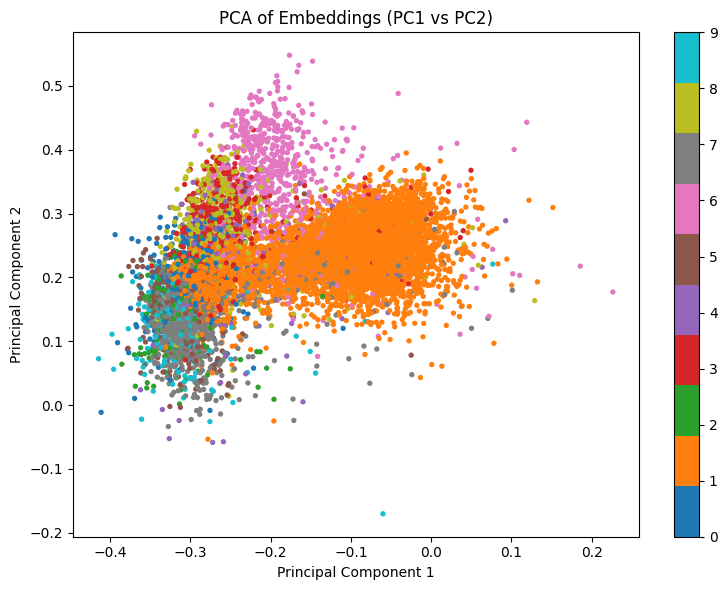

Explained variance (PC1, PC2): [0.944366   0.01517255]


In [ ]:
#PCA
from sklearn.decomposition import PCA
pca = PCA(n_components = 2)
X_train_pca = pca.fit_transform(X)

#Create a scatter plot of PC1 vs PC2 colored by diagnosis, where malignant = red, and benign = blue
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], 
            X[:, 1], 
            c=y, 
            cmap= 'tab10', 
            s = 8)
plt.colorbar()
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of Embeddings (PC1 vs PC2)')
plt.tight_layout()
plt.show()
print("Explained variance (PC1, PC2):", pca.explained_variance_ratio_)

Total explained variance by PCA compoents = 0.95. This is high, indicating that the PCA components capture most of the variance in the data. However, it may still miss the non-linear relationships that UMAP and t-SNE can capture. 

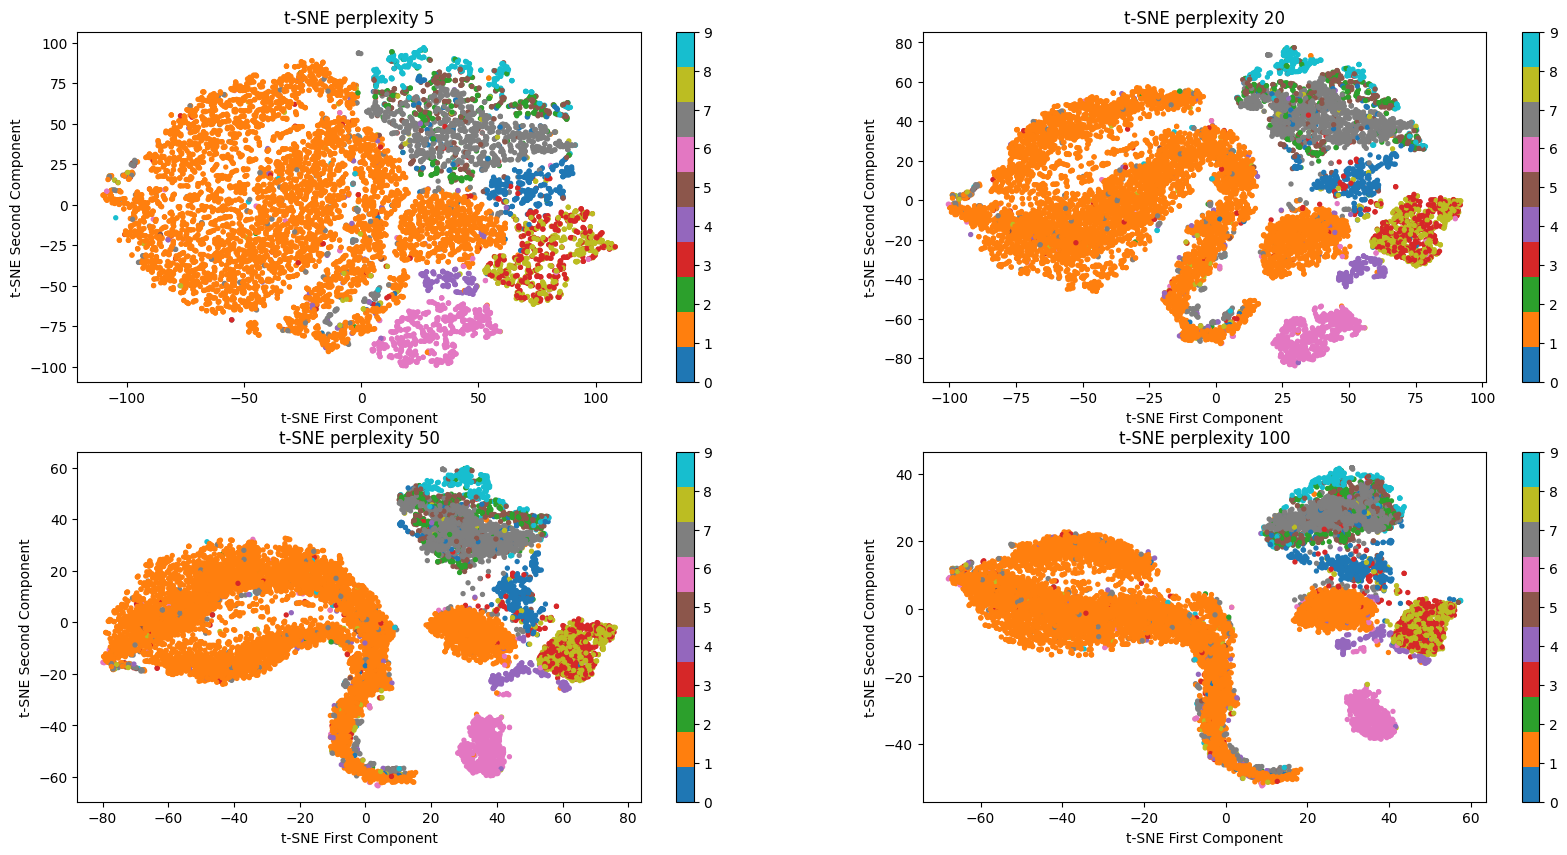

In [8]:
#t-sne 
from sklearn.manifold import TSNE
# Perplexity sweep on full dataset (caution: very slow overall)
perplexities = [5, 20, 50, 100]

plt.figure(figsize=(20, 10))
for i, perplexity in enumerate(perplexities):
    plt.subplot(2, 2, i+1)
    tsne = TSNE(n_components=2, random_state=42, perplexity=perplexity)
    tsne_model = tsne.fit_transform(X)
    plt.scatter(tsne_model[:, 0], tsne_model[:, 1], c=y, cmap='tab10', s=8)
    plt.colorbar()
    plt.xlabel('t-SNE First Component')
    plt.ylabel('t-SNE Second Component')
    plt.title(f't-SNE perplexity {perplexity}')
plt.show()

Tuning the hyperparameter for t-sne perplexity at 50 provided the best separation of clusters, especially between similar genomes. A higher perplexity value helps t-SNE to consider a broader context when positioning points, which is beneficial for datasets with varying densities.

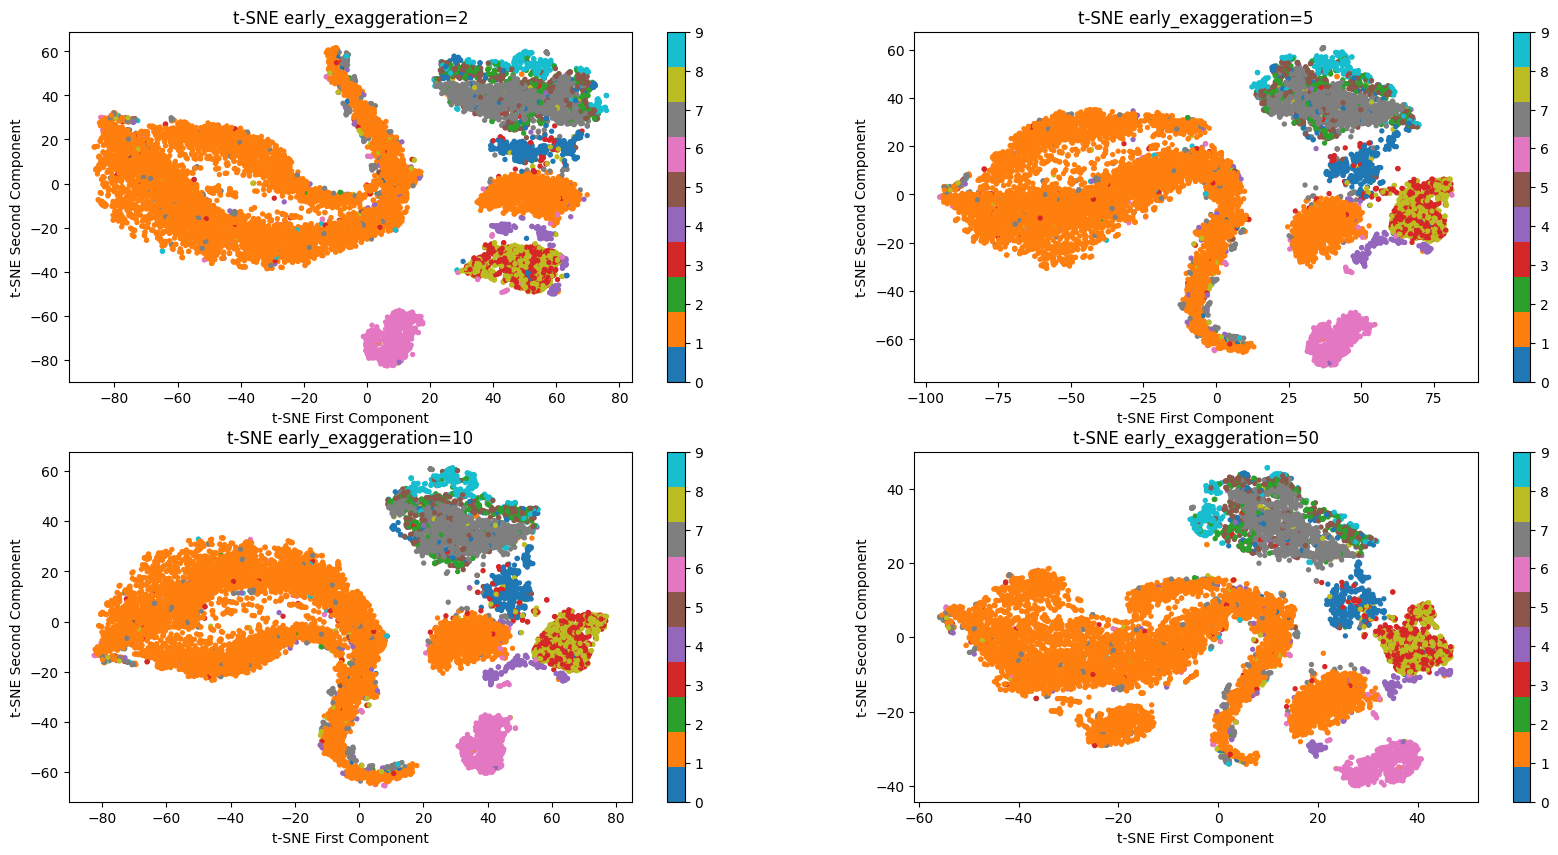

In [9]:
# Early exaggeration sweep on full dataset
early_exaggerations = [2, 5, 10, 50]

plt.figure(figsize=(20, 10))
for i, early_exaggeration in enumerate(early_exaggerations):
    plt.subplot(2, 2, i+1)
    tsne = TSNE(n_components=2, random_state=42, perplexity = 50, early_exaggeration=early_exaggeration)
    tsne_model = tsne.fit_transform(X)
    plt.scatter(tsne_model[:, 0], tsne_model[:, 1], c=y, cmap='tab10', s=8)
    plt.colorbar()
    plt.xlabel('t-SNE First Component')
    plt.ylabel('t-SNE Second Component')
    plt.title(f't-SNE early_exaggeration={early_exaggeration}')
plt.show()

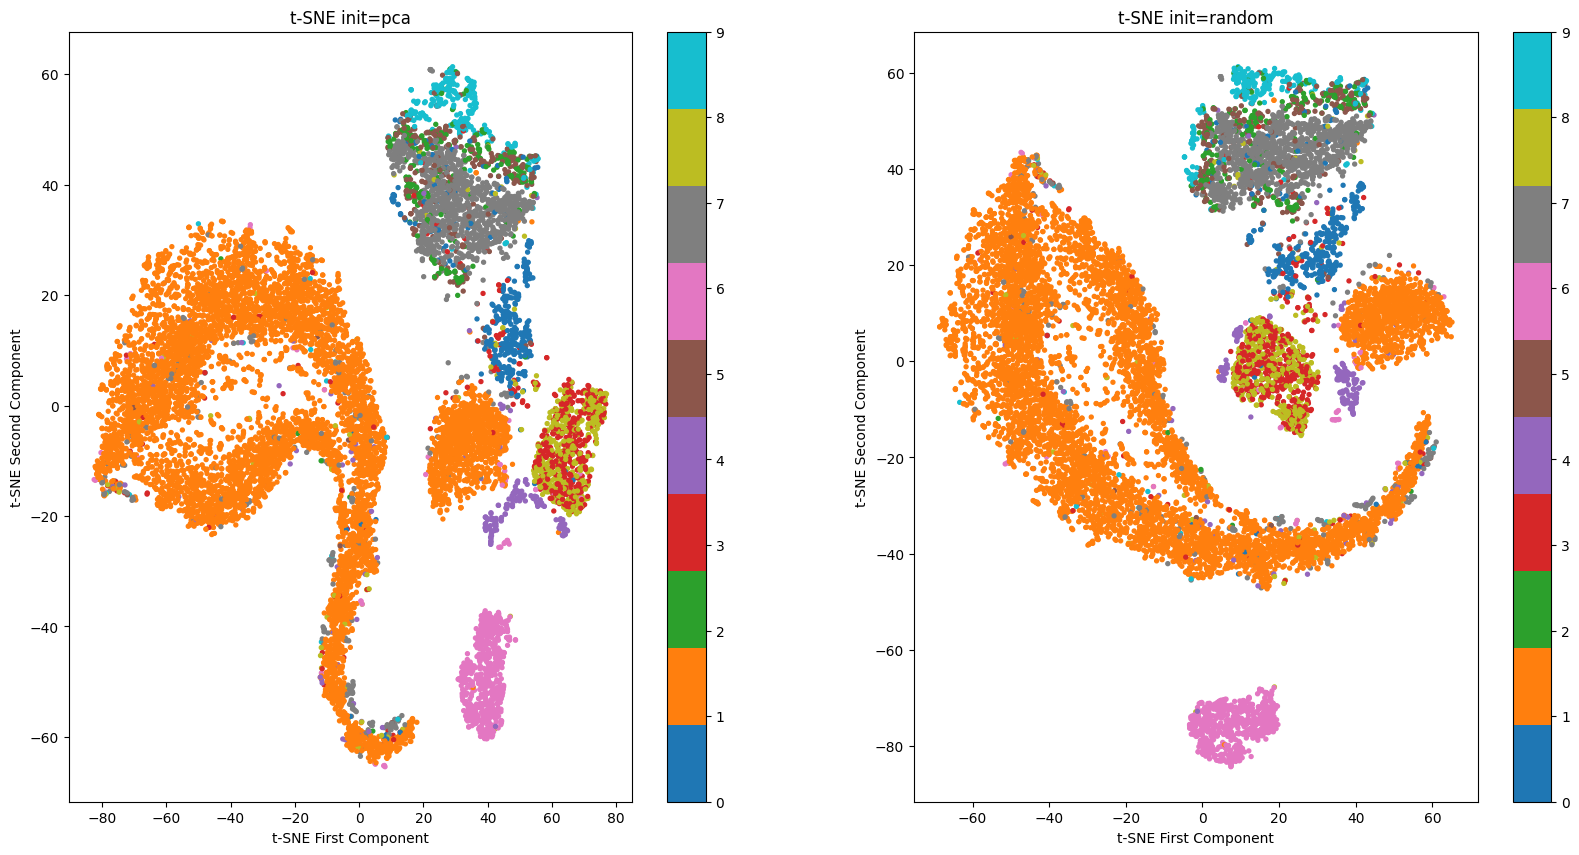

In [10]:
# Initialization comparison (PCA vs random) on full dataset
plt.figure(figsize=(20, 10))
for i, init in enumerate(['pca', 'random']):
    plt.subplot(1, 2, i+1)
    tsne = TSNE(n_components=2, random_state=42, perplexity=50, early_exaggeration= 10, init=init)
    tsne_model = tsne.fit_transform(X)
    plt.scatter(tsne_model[:, 0], tsne_model[:, 1], c=y, cmap='tab10', s=8)
    plt.colorbar()
    plt.xlabel('t-SNE First Component')
    plt.ylabel('t-SNE Second Component')
    plt.title(f't-SNE init={init}')
plt.show()

While tuning different hyperparameters for t-sne, I found that a perplexity of 50 and early exaggeration of 10 provided the clearest separation between clusters. The 'pca' initialization also helped in achieving better-defined clusters compared to 'random' initialization. These settings allowed t-SNE to effectively capture the local and global structure of the data, leading to more meaningful visualizations.

Text(0, 0.5, 't-SNE Second Component')

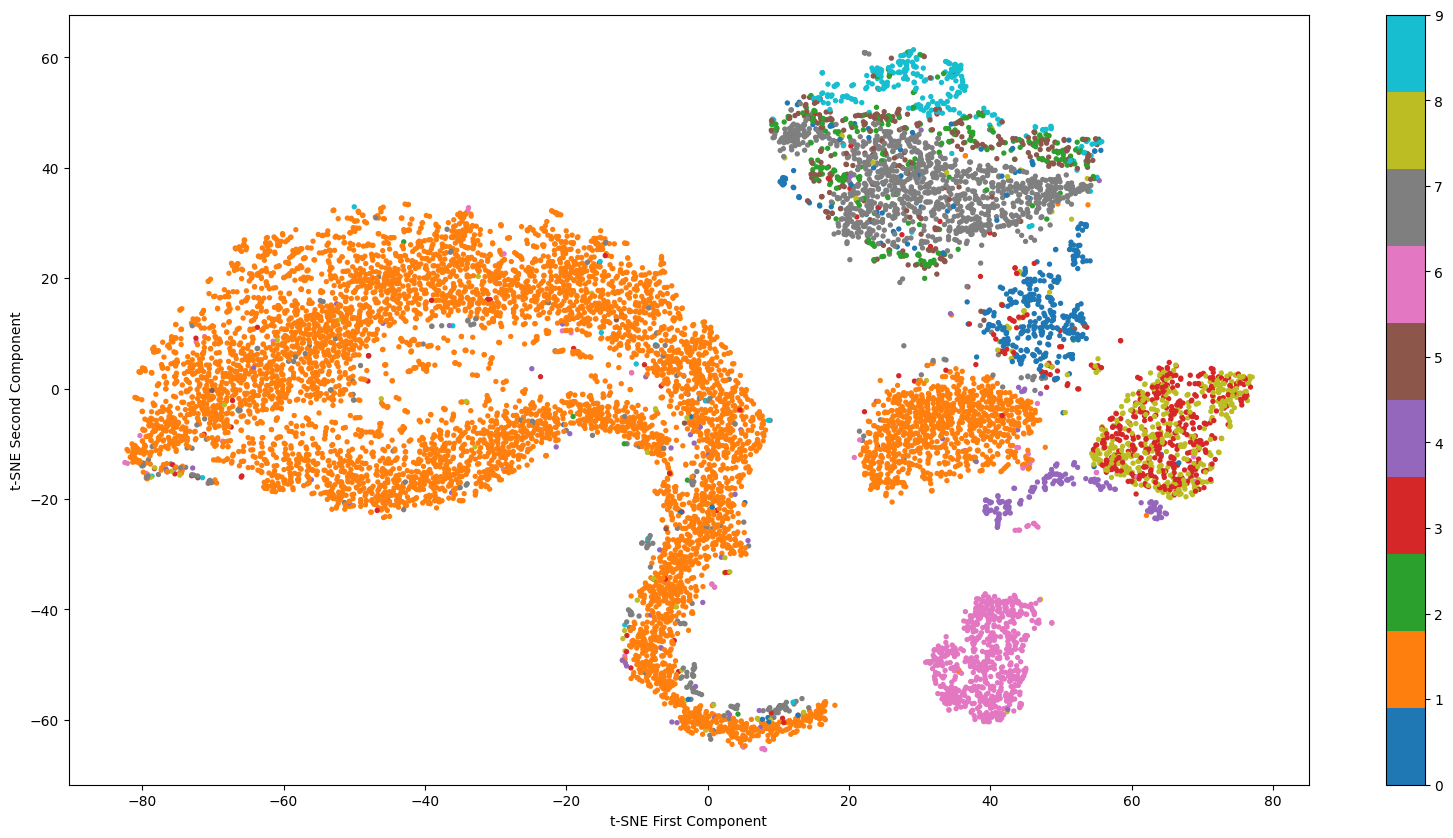

In [ ]:
#Final model, with best hyperparameters found perplexity = 50, early_exaggeration = 10, init = 'pca'
plt.figure(figsize=(20, 10)) 
tsne = TSNE(n_components=2, random_state=42, perplexity=50, early_exaggeration= 10, init='pca')
tsne_model = tsne.fit_transform(X)
plt.scatter(tsne_model[:, 0], tsne_model[:, 1], c=y, cmap='tab10', s=8)
plt.colorbar()
plt.xlabel('t-SNE First Component')
plt.ylabel('t-SNE Second Component')

/Users/benpilnick/Documents/Quarter/Fall_2025/stat362/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/benpilnick/Documents/Quarter/Fall_2025/stat362/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/benpilnick/Documents/Quarter/Fall_2025/stat362/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/benpilnick/Documents/Quarter/Fall_2025/stat362/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


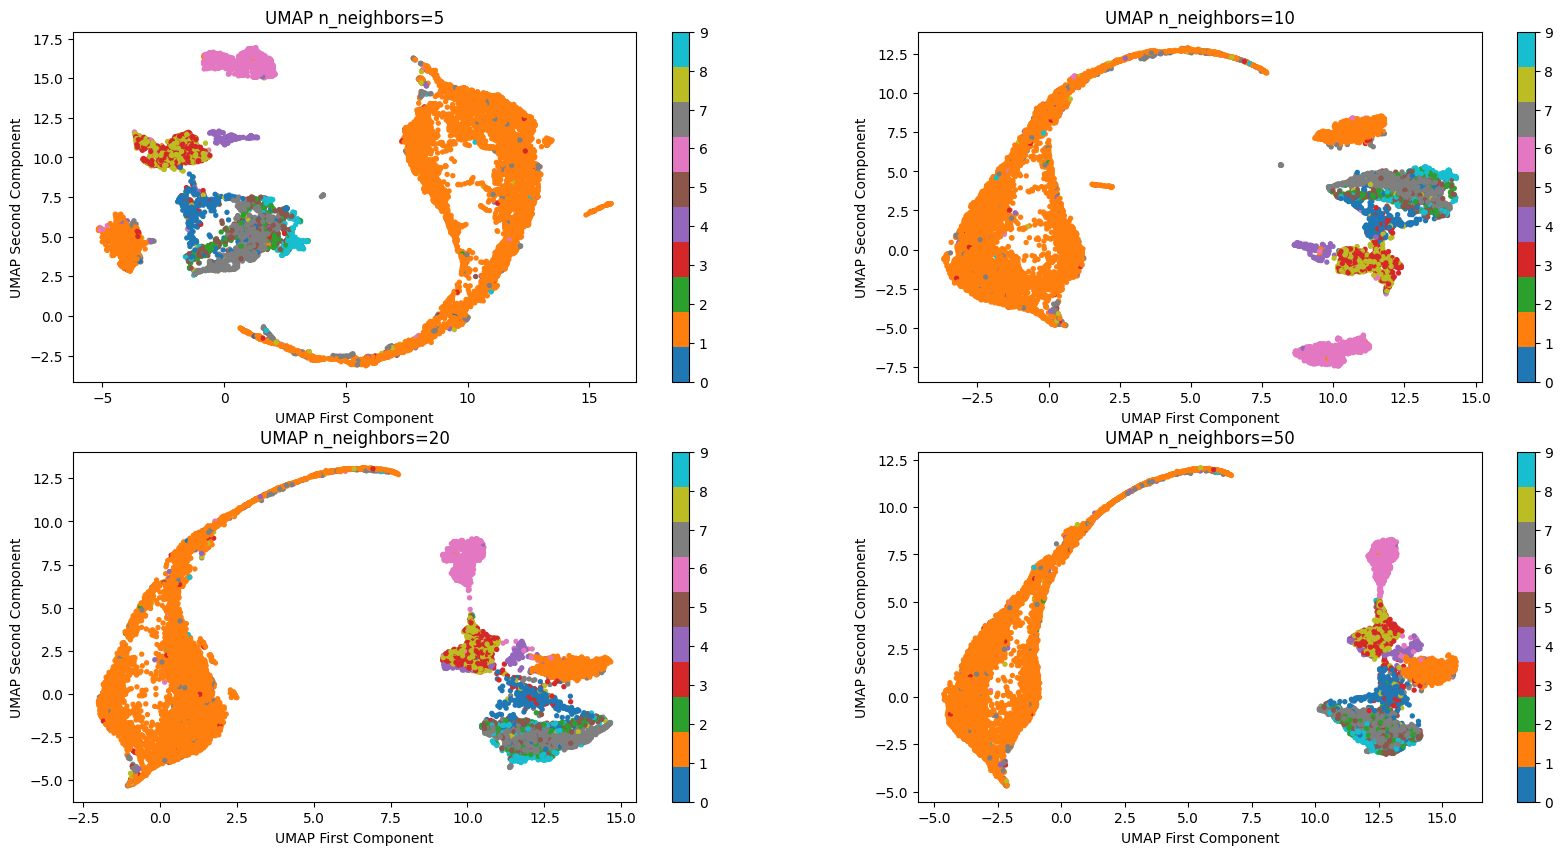

In [ ]:
#UMAP

import umap

#Visualize the data using UMAP

#Need to tune n_neighbors, min_dist, and metric. )
n_neighbors = [5, 10, 20, 50]

plt.figure(figsize=(20, 10))
for i, n_neighbor in enumerate(n_neighbors):
    plt.subplot(2, 2, i+1)
    umap2 = umap.UMAP(n_components=2, random_state=42, n_neighbors=n_neighbor)
    umap_model = umap2.fit_transform(X)
    plt.scatter(umap_model[:, 0], umap_model[:, 1], c=y, cmap='tab10', s=8)
    plt.colorbar()
    plt.xlabel('UMAP First Component')
    plt.ylabel('UMAP Second Component')
    plt.title(f'UMAP n_neighbors={n_neighbor}')
plt.show()

/Users/benpilnick/Documents/Quarter/Fall_2025/stat362/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/benpilnick/Documents/Quarter/Fall_2025/stat362/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/benpilnick/Documents/Quarter/Fall_2025/stat362/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/benpilnick/Documents/Quarter/Fall_2025/stat362/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


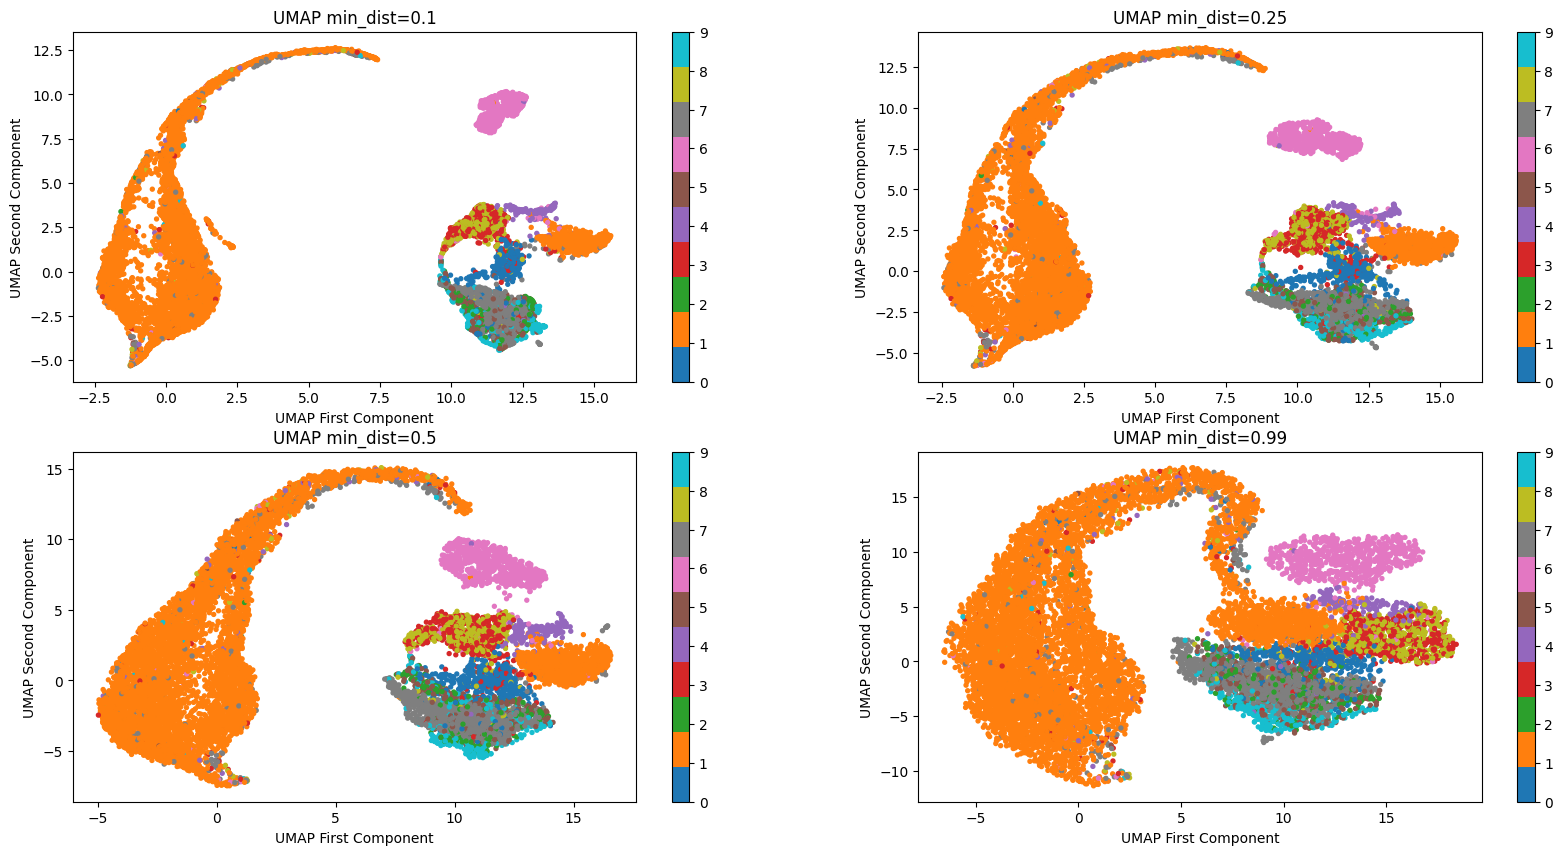

In [13]:
# UMAP min_dist sweep on full dataset
min_dists = [0.1, 0.25, 0.5, 0.99]

plt.figure(figsize=(20, 10))
for i, min_dist in enumerate(min_dists):
    plt.subplot(2, 2, i+1)
    umap3 = umap.UMAP(n_components=2, random_state=42, min_dist=min_dist)
    umap_model = umap3.fit_transform(X)
    plt.scatter(umap_model[:, 0], umap_model[:, 1], c=y, cmap='tab10', s=8)
    plt.colorbar()
    plt.xlabel('UMAP First Component')
    plt.ylabel('UMAP Second Component')
    plt.title(f'UMAP min_dist={min_dist}')
plt.show()

It's clear that n_neighbors = 20, min_dist = 0.5 is the best choice for UMAP in this dataset. This value balances local and global structure. 

/Users/benpilnick/Documents/Quarter/Fall_2025/stat362/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/benpilnick/Documents/Quarter/Fall_2025/stat362/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/benpilnick/Documents/Quarter/Fall_2025/stat362/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/benpilnick/Documents/Quarter/Fall_2025/stat362/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


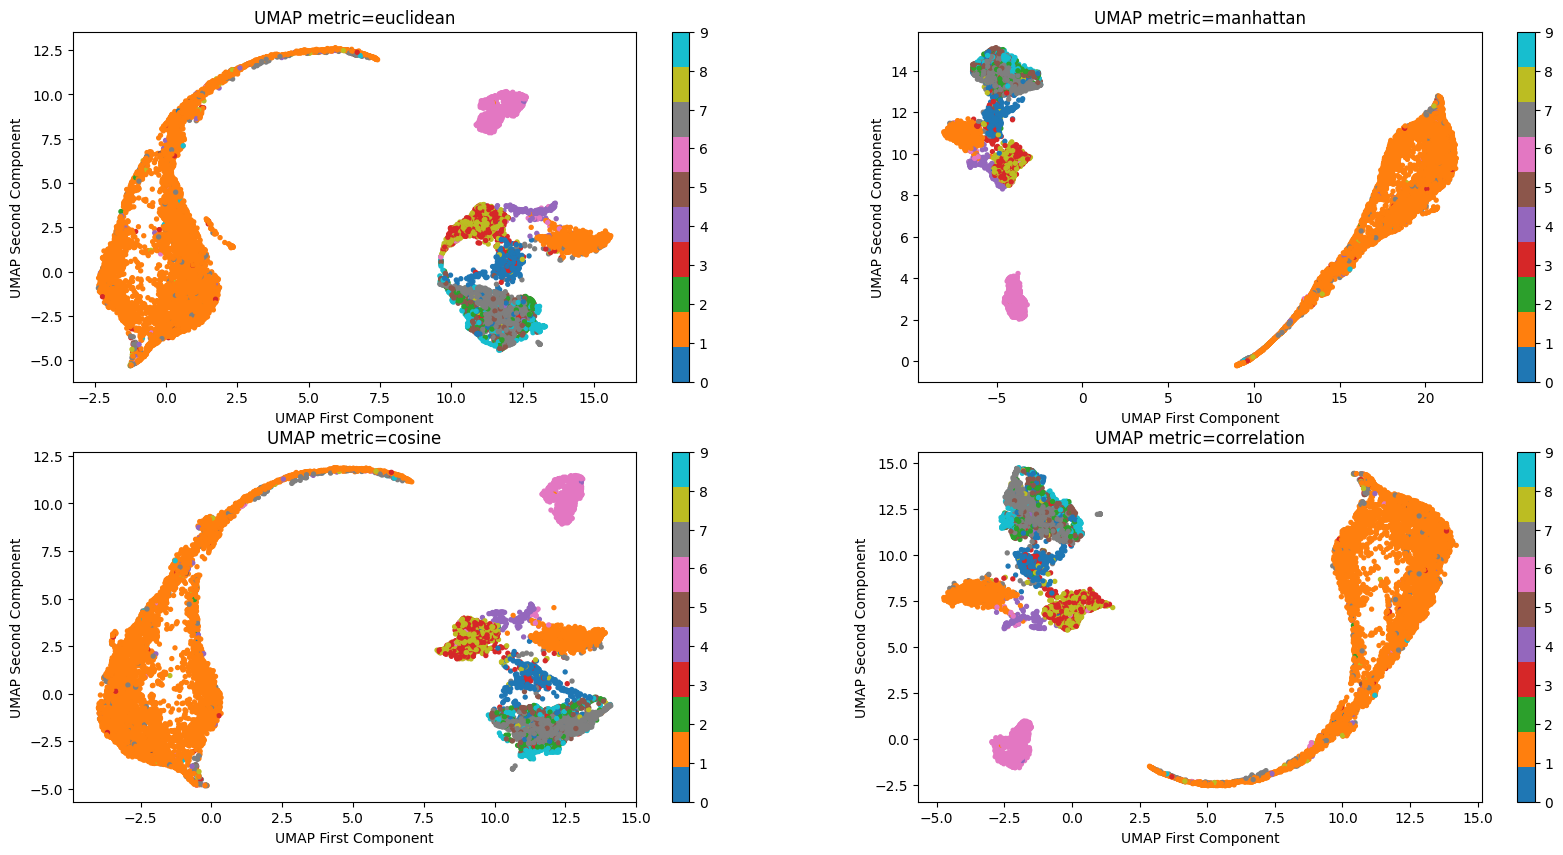

In [14]:
# UMAP metric sweep on full dataset
metrics = ['euclidean', 'manhattan', 'cosine', 'correlation']

plt.figure(figsize=(20, 10))
for i, metric in enumerate(metrics):
    plt.subplot(2, 2, i+1)
    umap4 = umap.UMAP(n_components=2, random_state=42, metric=metric)
    umap_model = umap4.fit_transform(X)
    plt.scatter(umap_model[:, 0], umap_model[:, 1], c=y, cmap='tab10', s=8)
    plt.colorbar()
    plt.xlabel('UMAP First Component')
    plt.ylabel('UMAP Second Component')
    plt.title(f'UMAP metric={metric}')
plt.show()


After experimenting with different distance metrics for UMAP, I found that the 'euclidean' metric provided the most distinct and well-separated clusters. This metric effectively captured the relationships in the data, leading to clearer visualizations compared to other metrics like 'manhattan' or 'cosine'. In addition, the n_neighbors and min_dist parameter were also tuned to 20, and 0.5 respecitively. 

/Users/benpilnick/Documents/Quarter/Fall_2025/stat362/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Text(0.5, 1.0, 'UMAP metric=correlation')

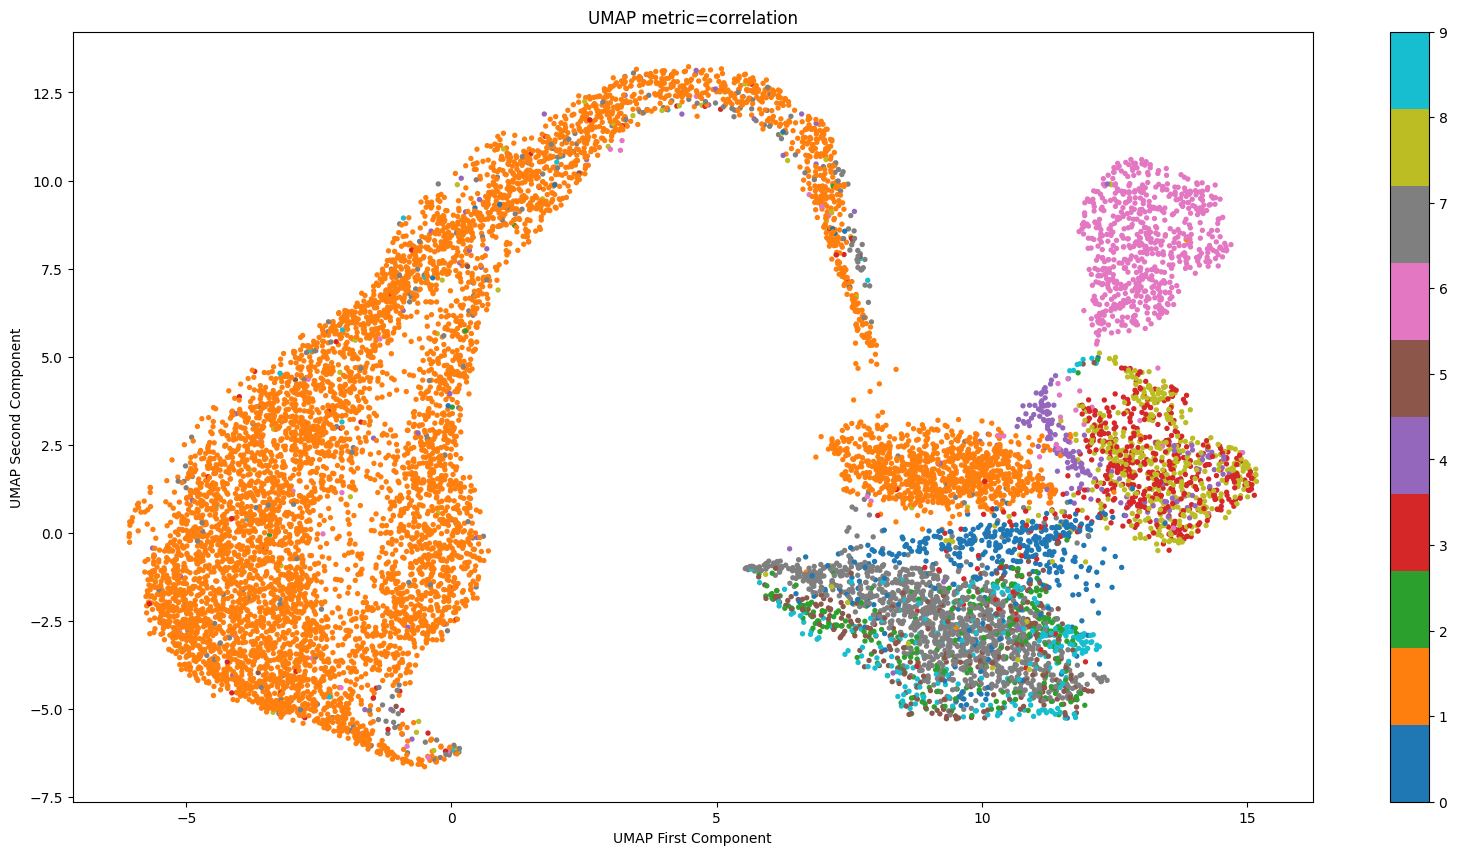

In [18]:
#Final model 
plt.figure(figsize=(20, 10))
umap4 = umap.UMAP(n_components=2, random_state=42, metric='euclidean', n_neighbors=20, min_dist=0.5)
umap_model = umap4.fit_transform(X)
plt.scatter(umap_model[:, 0], umap_model[:, 1], c=y, cmap='tab10', s=8)
plt.colorbar()
plt.xlabel('UMAP First Component')
plt.ylabel('UMAP Second Component')
plt.title(f'UMAP metric={metric}')

## Task 4: Evaluating Clustering Algorithms on 2D Embeddings (30 points)

Clustering algorithms often struggle with the curse of dimensionality, which can lead to poor performance on high-dimensional data.  
To address this, use the **2-dimensional representation** obtained from **t-SNE** in Task 2 (`n_components = 2`, `perplexity = 25`).

Apply **three different clustering algorithms** to the 2D data and evaluate their effectiveness.  
For each algorithm, report the following:

- **Visualization** of the clustering result (dimension = 2)
- **Number of clusters**
- **Number of outliers** (`cluster_labels == -1`, if applicable)
- **Completeness score** and **Homogeneity score**  
  (refer to scikit-learn documentation for how to compute these metrics given ground-truth labels)

**Note:**  
Since clustering is unsupervised, use the entire dataset when tuning hyperparameters (no train-test split needed).


In [ ]:
# There is no t-sne for task 2. Need to create the new model with n_componets = 2, and perplexity = 25. 
import numpy as np
from sklearn.manifold import TSNE   
tsne = TSNE(n_components=2, random_state=42, perplexity=25)


#Now fit the model, shape is now reduced to 2 dimensions. 
tsne_model = tsne.fit_transform(X)

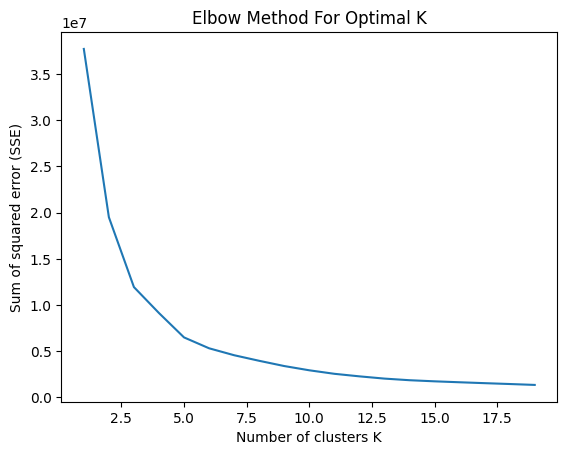

In [ ]:
#Three different clustering algorthms on the dimension reduced data. 

#Use Kmean

#We need to find the otpimal K value using the elbow method. 
# use the elbow method to find the optimal number of clusters 
from sklearn.cluster import KMeans

sse = []
k_rng = range(1, 20)
for k in k_rng:
    kmeans = KMeans(n_clusters=k, n_init=10)
    kmeans.fit(tsne_model)
    sse.append(kmeans.inertia_)

# plot the SSE for each n_clusters
plt.plot(k_rng, sse)
plt.xlabel('Number of clusters K')
plt.ylabel('Sum of squared error (SSE)')
plt.title('Elbow Method For Optimal K')
plt.show()

#From the elbow plot, we can see that the optimal K value is 5. 

In [36]:
#Lets use 4 for k. And lets do feature scaling using standard scaler. performance increases when all features are scaled, 
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(tsne_model)
kmeans = KMeans(n_clusters=5, n_init=15)
y_kmeans = kmeans.fit_predict(X_scaled)

K-means Clustering Performance:
Homogeneity Score: 0.42
Completeness Score: 0.38


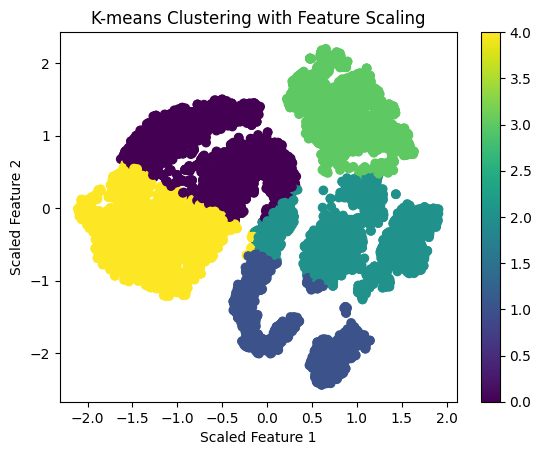

In [ ]:

plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y_kmeans, cmap='viridis')
plt.title('K-means Clustering with Feature Scaling')
plt.xlabel('Scaled Feature 1')
plt.ylabel('Scaled Feature 2')
plt.colorbar()

from sklearn.metrics import homogeneity_score, completeness_score
h_score = homogeneity_score(y, y_kmeans)
c_score = completeness_score(y, y_kmeans)
print("K-means Clustering Performance:")
print(f'Homogeneity Score: {h_score:.2f}')
print(f'Completeness Score: {c_score:.2f}')
#Outliers not applicable here. 

In [ ]:
#DBSCAN clustering
from sklearn.cluster import DBSCAN
dbscan = DBSCAN(eps=0.20) #Found optimal eps value by testing different eps and looking at the graph. Any number above 0.22 will result in one major cluster. 


# using scaled data. 
labels_normal = dbscan.fit_predict(X_scaled)

DBSCAN Clustering Performance:
Homogeneity Score: 0.34
Completeness Score: 0.58
Number of outliers: 0


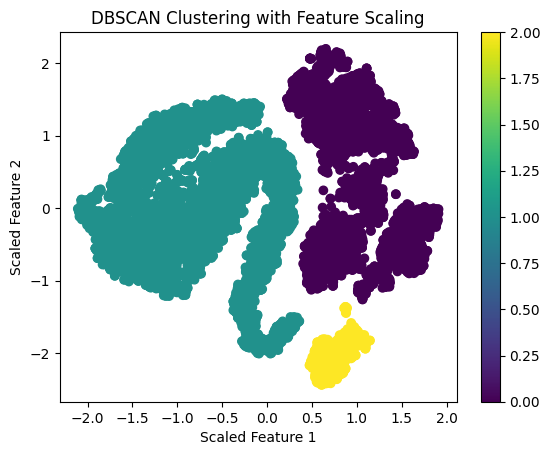

In [77]:
#Plot results/ output performance metrics of homogeneity and completeness
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels_normal, cmap='viridis')
plt.title('DBSCAN Clustering with Feature Scaling')
plt.xlabel('Scaled Feature 1')
plt.ylabel('Scaled Feature 2')
plt.colorbar()
h_score_db = homogeneity_score(y, labels_normal)
c_score_db = completeness_score(y, labels_normal)
print("DBSCAN Clustering Performance:")
print(f'Homogeneity Score: {h_score_db:.2f}')
print(f'Completeness Score: {c_score_db:.2f}')

num_outliers = (labels_normal == -1).sum()
print("Number of outliers:", num_outliers)

Agglomerative Clustering Performance:
Homogeneity Score: 0.54
Completeness Score: 0.38


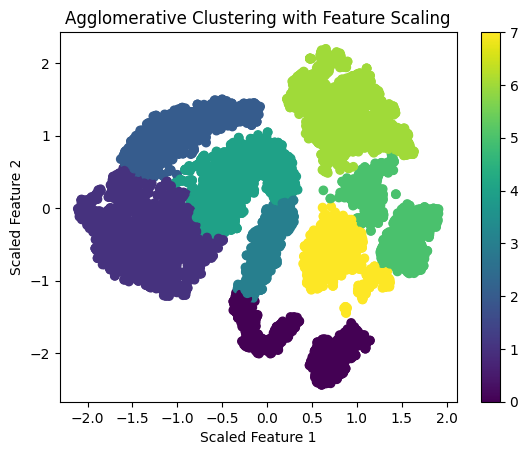

In [ ]:
#Agglomerative Clustering
from sklearn.cluster import AgglomerativeClustering
agglo = AgglomerativeClustering(n_clusters=8)
labels_agglo = agglo.fit_predict(X_scaled)

#Plot results/ output performance metrics of homogeneity and completeness
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels_agglo, cmap='viridis')
plt.title('Agglomerative Clustering with Feature Scaling')
plt.xlabel('Scaled Feature 1')
plt.ylabel('Scaled Feature 2')
plt.colorbar()
h_score_agglo = homogeneity_score(y, labels_agglo) 
c_score_agglo = completeness_score(y, labels_agglo)
print("Agglomerative Clustering Performance:")
print(f'Homogeneity Score: {h_score_agglo:.2f}')
print(f'Completeness Score: {c_score_agglo:.2f}') 

#Outliers not applicable here

## Task 5: Summary of Best Results and Reflection (10 points)

Summarize the best results you obtained from each of the previous tasks and explain what you learned from this assignment.


**Task1**
After building and testing multiple classification models, I found that the Multinomial Logistic Regression model performed the best overall. It achieved a macro F1 score of 0.89, with high precision and recall scores as well. This indicates that the model was effective at correctly classifying contigs from different genomes in the Zymo mock community dataset. Other models like LightGBM, XGBoost, and Catboost also performed well, but on average of other metrics like accuracy, precision, and recall, the Multinomail Logistic Regression stood out as the to p performer. 

**Tasks2:** 
Introdcuing dimensionality reduction techniques like PCA and UMAP signficantly improved classification efficiency without sacrificing much accuracy (multinomial regression model). Overall. PCA performed better than UMAP across most n_components settings, achieving higher macro F1 scores. The best-performing n_compnonents =200 for PCA, achieving a macro F1 score of 0.90, while UMAP's best was at n_components = 10, with macro F1 scores of 0.60. The reduction in dimensionality led to faster training times, making it practical for large datasets like this one. 

**Task3:**
We were tasked with visualizing the high-dimensional embeddings using PCA, t-SNE, and UMAP. After experimenting with different hyperparameters, I found that t-SNE with a perplexity of 50 and early exaggeration of 10 provided the clearest separation between clusters. The inititalization hyperparameter had little impact on performance and seperation between clusters. For PCA, it captured a signficant amount of variaance (95%), but the clusters were not seperated as clearly as with t-SNE and UMAP. For UMAP, we used euclidean metric with n_neighbors = 20 and min_dist = 0.5, which provided better cluster seperation comapared to other combinations. Overall, t-SNE provided the most informative visualizations for this dataset.

**Task4:**
For clustering the 2D t-SNE embeddings, I applied KMeans, DBSCAN, and Agglomerative Clusterings. Agglomerative Clustering performed the best, achieiving a homogenity score of 0.54 and completeness score of 0.52. Kmeans performed signficantly worsed compared to both Kmeans and DBSCAN. For Kmeans we identified using the elbow technique that 5 clusters was optimal. However, the homogenity and completeness scores were low, indiciating poor alignment. DBSCAN also perfomred moderately well, but had 3 different clusters. 